### Multivariate LTSM For Predicting Future CPU Usage

Phase 4A: 
Forecast 1 hour ahead
We will use: Last 12 observations
because:
12 × 5 minutes = 1 hour history
Model sees: Previous 1 hour and predicts:
Next CPU state

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
# After scaling:

# The smallest value becomes 0
# The largest value becomes 1
# All other values fall between 0 and 1

from sklearn.metrics import (
    mean_absolute_error,    # how far predictions are from actual values (on average)
    mean_squared_error, # It calculates the average of 
    # squared differences between actual and predicted values, Penalizes big errors more heavily (because of squaring)
    r2_score    # Measures how well the model explains the variance in the data: Compares your model to a baseline model (mean prediction)
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)

In [2]:
# Load Feature Dataset
df = pd.read_csv(
    "../data/Processed/cpu_features.csv"
)

df["ts"] = pd.to_datetime(
    df["ts"],
    format="mixed",
    utc=True
)

In [3]:
# Sort chronologically
df = df.sort_values(
    ["hostName", "ts"]
)
# Sorts the dataset by:
# hostName first
# Then ts (timestamp) within each host

df = df.reset_index(drop=True)
# Removes the old row index and replaces it with a new sequential index (0, 1, 2, …)

In [4]:
# Select Features
FEATURES = [
    "cpu_usage_pct",
    "memory_usage_pct",
    "power_kw",
    "cpu_temp_c",
    "inlet_temp_c",
    "cpu_lag_1",
    "cpu_lag_2",
    "cpu_change",
    "cpu_acceleration",
    "cpu_volatility",
    "cpu_memory_ratio",
    "thermal_gradient",
    "temp_rate_of_change",
    "cpu_per_kw",
    "temp_per_cpu",
    "resource_stress_index"
]

TARGET = "cpu_usage_pct"

In [5]:
# Extract Data
data = df[FEATURES]

In [6]:
# Scale Data
# LSTMs require normalised inputs
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)
# fit(): learns minimum value and maximum value of each feature from the data
# transform(): applies the scaling to the data based on the learned min and max values

Create Sequences
We want:
Previous 12 observations which equals: 1 hour history because: 12 × 5 minutes
Example: Input:
t1
t2
t3
...
t12
Predict: t13

In [7]:
# Sequence Function, create sequences per server

# Sequence: CPU: time-series data, so instead of giving 1 row, we give a window of history
# so model learns increasing trend and predicts CPU likely continues rising or starts falling

# Creates input sequences (X) and target values (y):
# Separately for each hostName (server)
# Used for training an LSTM to predict CPU usage

def create_sequences_per_server(
    df,
    features,
    sequence_length=12
):
    # initialize list
    X = []  # X -> input sequences (for LSTM)
    y = []  # Y -> target values (what we want to predict)

    for host in df["hostName"].unique():    # Processes each server separately
        server_df = df[
            df["hostName"] == host
        ].copy()
        server_df = server_df.sort_values(
            "ts"
        )
        # Gets all rows for that server
        # Sorts by time (ts) ✅ critical for time series

        scaler = MinMaxScaler()
        scaled = scaler.fit_transform(
            server_df[features]
        )
        # find target column index

        target_index = features.index(
            "cpu_usage_pct"
        )
# Create a a slifing window of sequences and targets
        for i in range(
            sequence_length,
            len(scaled)
        ):
            X.append(
                scaled[
                    i-sequence_length:i
                ]
            )  
            # Take the last sequence_length rows (12)
            # Shape = (sequence_length, number of features)
            #  X = [[t1, t2, t3, ..., t12]]
            
            y.append(
                scaled[
                    i,
                    target_index
                ]
            )
            # take the next time step, only the cpu_usage_pct value

    return (
        np.array(X),    # X-shape: (num_samples, sequence_length, num_features)
        np.array(y)     # Y shape = (num_samples,)
    )

# If:
# sequence_length = 3
# data = [10, 20, 30, 40]

# You get:
# X = [
#   [10, 20, 30]
# ]

# y = [40]

In [8]:
X, y = create_sequences_per_server(
    df,
    FEATURES,
    sequence_length=12
)

In [9]:
# Verify shapes
print(X.shape)
print(y.shape)

(74216, 12, 16)
(74216,)


In [10]:
# Train-test split
train_size = int(
    len(X) * 0.8
)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [11]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(59372, 12, 16)
(14844, 12, 16)
(59372,)
(14844,)


In [12]:
# Build the LSTM model
model = Sequential()
model.add(
    LSTM(
        64,
        return_sequences=True,  # Returns output for every time step
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )   # considered (sequence_length, num_features) -> 12 time steps, features per step
    )
)
model.add(
    Dropout(0.2)
)
model.add(  # another smaller LSTM layer
    LSTM(32)
) # output shape = (num_samples, 32)
model.add(
    Dropout(0.2)
)
model.add(
    Dense(16, activation="relu")    # fully connected layer with 16 neurons and ReLU activation
)
model.add(
    Dense(1)
)   # Produces final prediction
# total outputs = number of sequences (samples)

c:\Users\Avilasha\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,697 (131.63 KB)

 Trainable params: 33,697 (131.63 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Early Stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    # The model watches validation loss
    # val_loss = error on validation data (not training data)
    patience=5, # waiting period -> if validation loss does NOT improve for 5 epochs -> stop training
    restore_best_weights=True
    
)

In [16]:
# Training Cell
history = model.fit(
    X_train,
    y_train,

    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1   # for progress bar
)

Epoch 1/30
743/743 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0040 - mae: 0.0417 - val_loss: 0.0022 - val_mae: 0.0322
Epoch 2/30
743/743 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0034 - mae: 0.0382 - val_loss: 0.0044 - val_mae: 0.0548
Epoch 3/30
743/743 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0033 - mae: 0.0375 - val_loss: 0.0019 - val_mae: 0.0231
Epoch 4/30
743/743 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0033 - mae: 0.0368 - val_loss: 0.0020 - val_mae: 0.0271
Epoch 5/30
743/743 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0033 - mae: 0.0367 - val_loss: 0.0021 - val_mae: 0.0256
Epoch 6/30
743/743 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0032 - mae: 0.0363 - val_loss: 0.0018 - val_mae: 0.0219
Epoch 7/30
743/743 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0032 - mae: 0.0361 - val_loss: 0.0018 - val_mae: 0.0212
Epoch 8/30
743/743 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0031 - mae: 0.0357 - val_loss: 0.0026 - val_mae: 0.0395
Epoch 9/30
743/743 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/ste

In [17]:
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

Prediction and Forecasting

In [18]:
# Generate Predictions
y_pred = model.predict(X_test)
print(y_pred.shape)

464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
(14844, 1)


In [19]:
# Flatten predictions
y_pred = y_pred.flatten()
print(y_pred.shape)

(14844,)


Evaluate Model Predictions

In [20]:
# MAE
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
mae = mean_absolute_error(
    y_test,
    y_pred
)
print("MAE:", mae)

MAE: 0.010144107633078889


In [21]:
# RMSE
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)
print("RMSE:", rmse)

RMSE: 0.029763741878909747


In [22]:
# R2 Score
r2 = r2_score(
    y_test,
    y_pred
)
print("R2 Score:", r2)

R2 Score: 0.5465477276724351


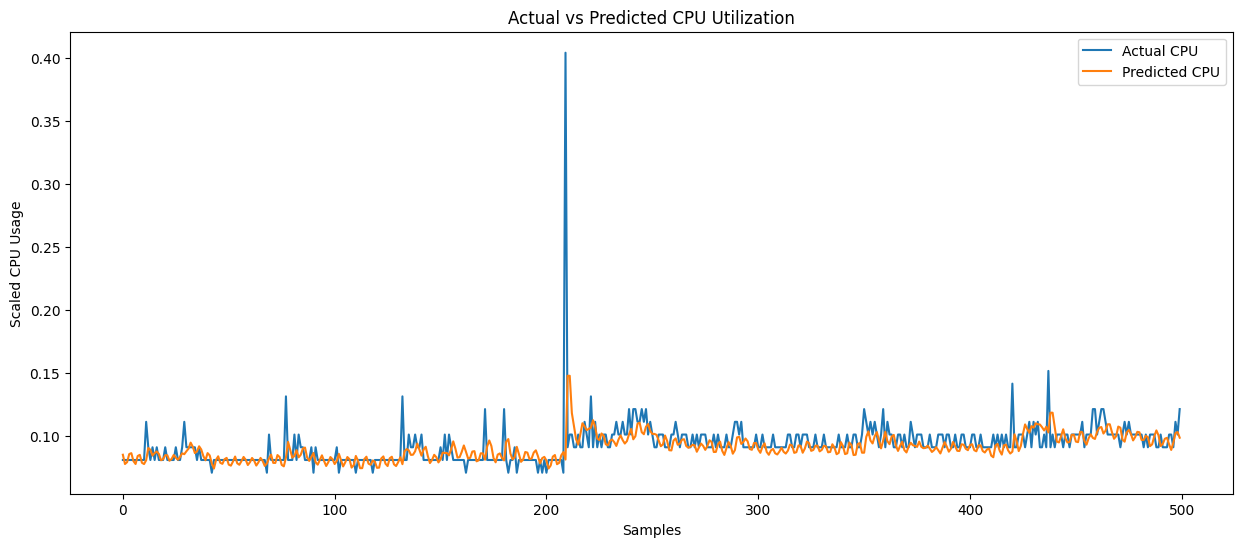

In [23]:
# Visualize Forecast Performance
plt.figure(figsize=(15,6))
plt.plot(
    y_test[:500],
    label="Actual CPU"
)
plt.plot(
    y_pred[:500],
    label="Predicted CPU"
)
plt.title(
    "Actual vs Predicted CPU Utilization"
)

plt.xlabel("Samples")
plt.ylabel("Scaled CPU Usage")
plt.legend()
plt.show()

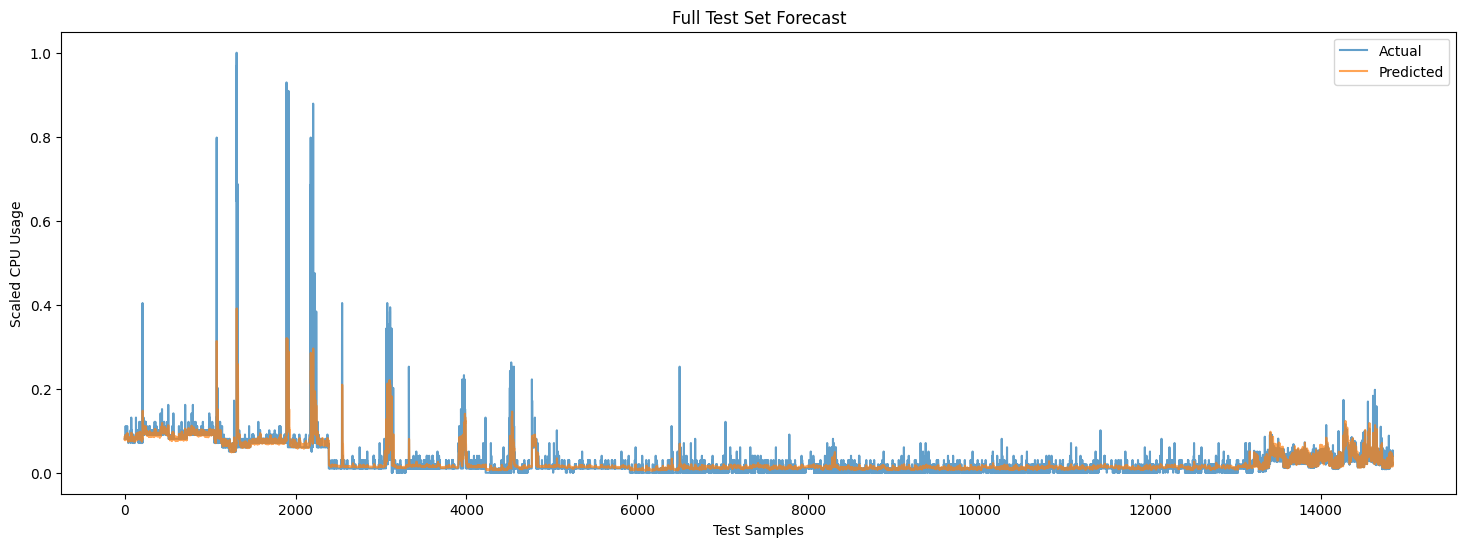

In [24]:
# Full Timeline Actual vs Predicted

plt.figure(figsize=(18,6))

plt.plot(
    y_test,
    label="Actual",
    alpha=0.7
)

plt.plot(
    y_pred,
    label="Predicted",
    alpha=0.7
)

plt.title("Full Test Set Forecast")
plt.xlabel("Test Samples")
plt.ylabel("Scaled CPU Usage")

plt.legend()
plt.show()

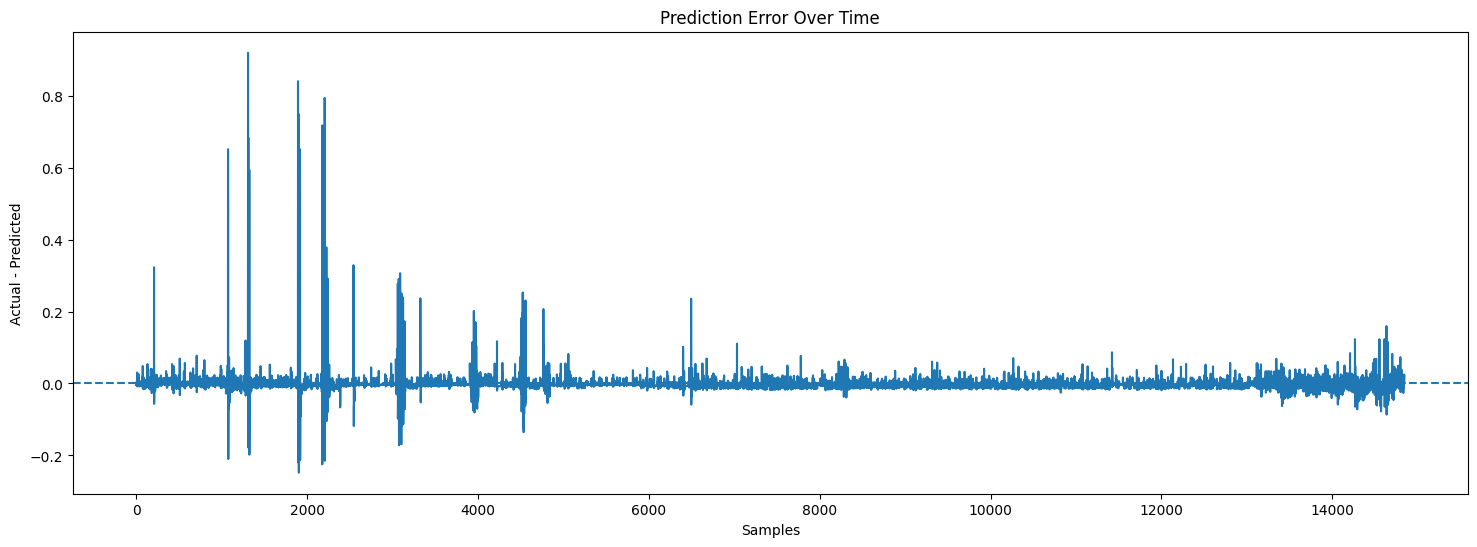

In [25]:
# prediction error plot
errors = y_test - y_pred

plt.figure(figsize=(18,6))

plt.plot(errors)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Prediction Error Over Time")
plt.xlabel("Samples")
plt.ylabel("Actual - Predicted")

plt.show()

# Above 0  → Underprediction
# Below 0  → Overprediction

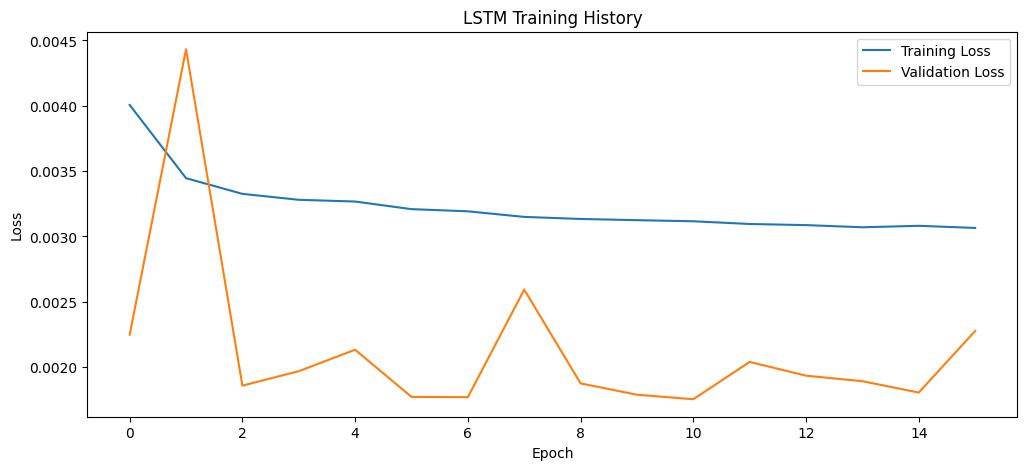

In [26]:
# Training History Plot
plt.figure(figsize=(12,5))
plt.plot(
    history.history["loss"],
    label="Training Loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

CPU Overload Prediction

In [27]:
# threshold to be defined
CPU_THRESHOLD = 0.80
future_overloads = (
    y_pred > CPU_THRESHOLD
)
print(
    "Predicted Overload Events:",
    future_overloads.sum()
)

Predicted Overload Events: 0


In [ ]:
# summarizing the distribution of your target values (y_test)
print(y_test.min())
print(y_test.max()) # min and max of normalised values
print(y_test.mean())
print(np.percentile(y_test,95)) # 95th percentile   means 95% of values are less than this
print(np.percentile(y_test,99)) # 99th percentile   only top 1% go above this

0.0
1.0
0.026172633094621776
0.09090909090909093
0.12121212121212123


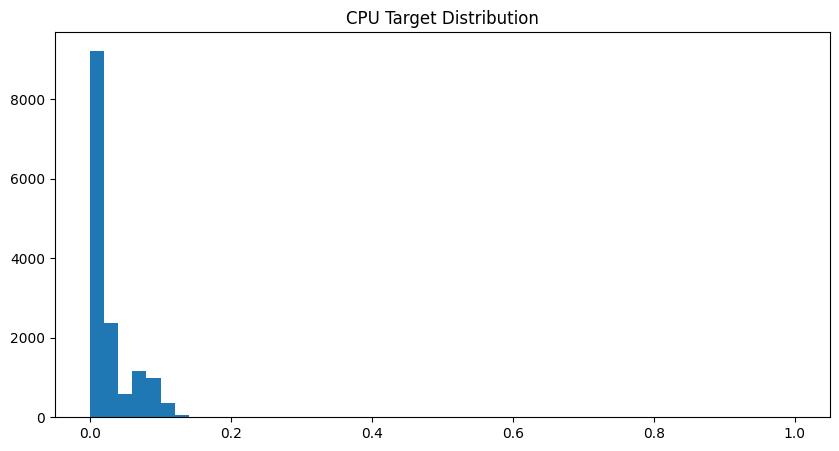

In [29]:
plt.figure(figsize=(10,5))

plt.hist(y_test,bins=50)

plt.title("CPU Target Distribution")

plt.show()